In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv('../data/raw/02_nav_history.csv')
transactions = pd.read_csv('../data/raw/08_investor_transactions.csv')
performance = pd.read_csv('../data/raw/07_scheme_performance.csv')
holdings = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [3]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [4]:
var_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    var95 = np.percentile(
        temp,
        5
    )

    cvar95 = temp[
        temp <= var95
    ].mean()

    var_results.append([
        fund,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_df.to_csv(
    '../reports/var_cvar_report.csv',
    index=False
)

In [6]:
top5 = [
    'Axis Bluechip Fund',
    'HDFC Top 100 Fund',
    'ICICI Bluechip Fund',
    'Kotak Bluechip Fund',
    'SBI Bluechip Fund'
]

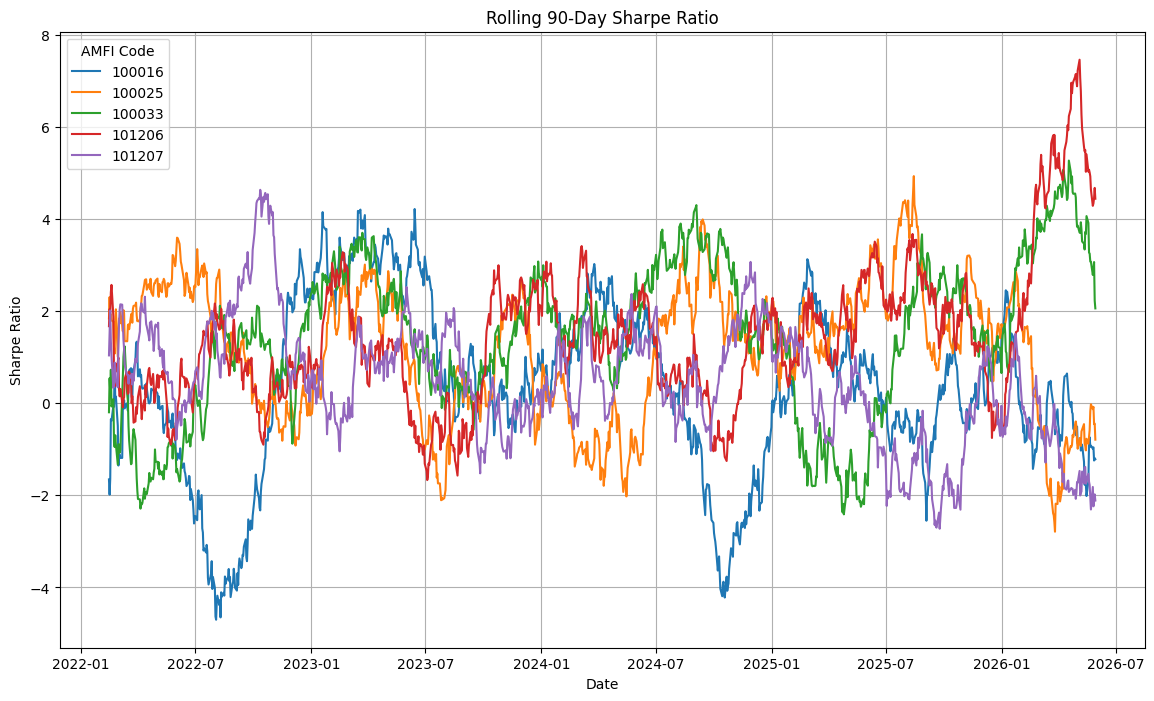

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(14,8))

for fund in top5:

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    if len(temp) < 30:
        continue

    rolling_sharpe = (
        temp['daily_return']
        .rolling(window=90, min_periods=30)
        .mean()
        /
        temp['daily_return']
        .rolling(window=90, min_periods=30)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(title='AMFI Code')
plt.grid(True)

plt.savefig(
    '../charts/rolling_sharpe_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
transactions['first_year'] = (
    transactions.groupby(
        'investor_id'
    )['transaction_date']
    .transform('min')
    .dt.year
)

In [11]:
cohort = (
    transactions
    .groupby('first_year')
    .agg({
        'amount_inr':'mean'
    })
)

cohort

,amount_inr
first_year,
2024,107422.541832
2025,109158.577061


In [12]:
cohort['total_invested'] = (
    transactions
    .groupby('first_year')
    ['amount_inr']
    .sum()
)

In [13]:
sip = transactions[
    transactions['transaction_type']
    == 'SIP'
].copy()

In [14]:
sip = sip.sort_values(
    ['investor_id',
     'transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [15]:
continuity = (
    sip.groupby('investor_id')
    ['gap_days']
    .mean()
    .reset_index()
)

In [16]:
continuity['status'] = np.where(
    continuity['gap_days'] > 35,
    'At Risk',
    'Healthy'
)

continuity.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [6]:
import pandas as pd
import numpy as np

holdings = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

print(holdings.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [7]:
hhi = (
    holdings
    .groupby(
        'amfi_code'
    )['weight_pct']
    .apply(
        lambda x:
        np.sum(
            (x/100)**2
        )
    )
    .reset_index()
)

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [8]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


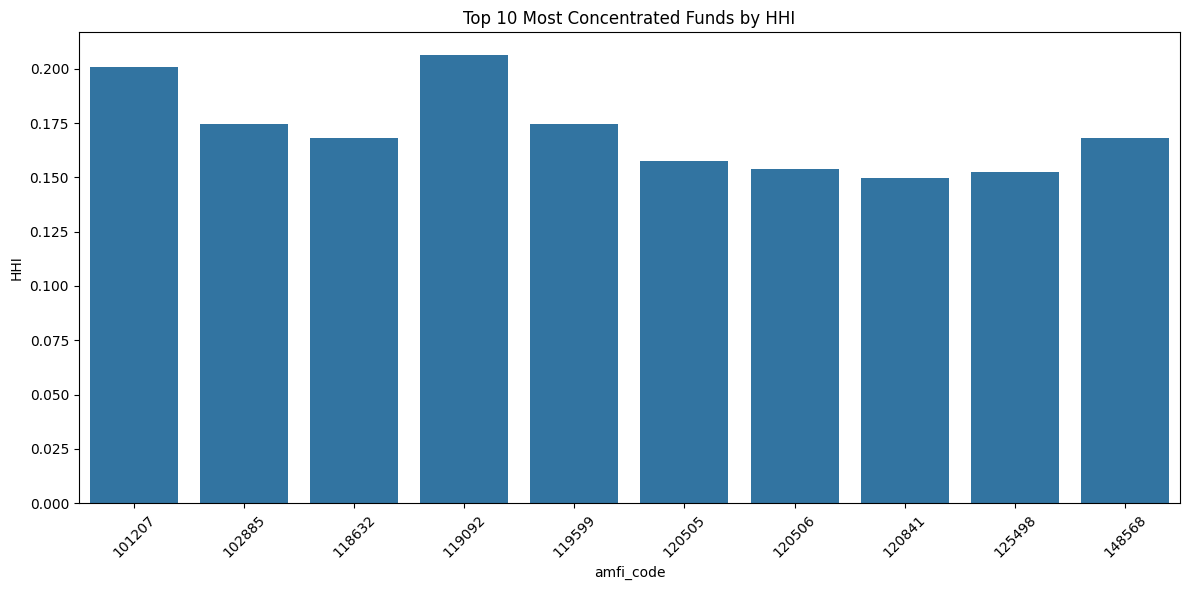

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

top_hhi = hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_hhi,
    x='amfi_code',
    y='HHI'
)

plt.title(
    'Top 10 Most Concentrated Funds by HHI'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../charts/hhi_concentration.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Insight 1
Funds with higher HHI values exhibit greater portfolio concentration, indicating heavier allocation to a smaller number of sectors or holdings. Funds with lower HHI values are more diversified and may offer lower concentration risk.

## Insight 2
Funds with the highest VaR and CVaR exhibited greater downside risk and higher loss potential during adverse market conditions.

## Insight 3
Recent investor cohorts contributed the highest total investment amounts, reflecting increasing mutual fund participation.

## Insight 4
SIP continuity analysis showed that most investors maintained monthly contribution discipline, while a subset was classified as at-risk.

## Insight 5
Funds with higher Sharpe Ratios consistently delivered better risk-adjusted returns compared to peers.

## Insight 6
Highly concentrated portfolios displayed larger HHI values, indicating increased sector-specific exposure and risk.
